In [ ]:
# Task 1 — Data Loading & Exploration 

In [5]:
import pandas as pd

In [7]:
# Load dataset
df = pd.read_csv(r"C:\Users\Kanchan\Downloads\Housing.csv")

In [8]:
# First 10 rows
print(df.head(10))

      price   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000   7420         4          2        3      yes        no       no   
1  12250000   8960         4          4        4      yes        no       no   
2  12250000   9960         3          2        2      yes        no      yes   
3  12215000   7500         4          2        2      yes        no      yes   
4  11410000   7420         4          1        2      yes       yes      yes   
5  10850000   7500         3          3        1      yes        no      yes   
6  10150000   8580         4          3        4      yes        no       no   
7  10150000  16200         5          3        2      yes        no       no   
8   9870000   8100         4          1        2      yes       yes      yes   
9   9800000   5750         3          2        4      yes       yes       no   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      

In [9]:
# Shape
print("Rows, Columns:", df.shape)

Rows, Columns: (545, 13)


In [10]:
# Columns
print(df.columns)

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')


In [14]:
# Missing values
print(df.isnull().sum())

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [12]:
# Target column
target = "price"
features = [col for col in df.columns if col != target]

print("Target:", target)
print("Features:", features)

Target: price
Features: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [ ]:
# Task 2 — Data Cleaning

In [15]:
# Duplicate Removal
df.drop_duplicates(inplace=True) 

In [34]:
# Check missing values
print(df.isnull().sum())

# No missing values found
print("Dataset contains no missing values.")

price                              0
area                               0
bedrooms                           0
bathrooms                          0
stories                            0
parking                            0
mainroad_yes                       0
guestroom_yes                      0
basement_yes                       0
hotwaterheating_yes                0
airconditioning_yes                0
prefarea_yes                       0
furnishingstatus_semi-furnished    0
furnishingstatus_unfurnished       0
dtype: int64
Dataset contains no missing values.


In [35]:
# Convert categorical columns (One hot encoding) 
df = pd.get_dummies(df, drop_first=True)

In [38]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   parking                          545 non-null    int64
 6   mainroad_yes                     545 non-null    bool 
 7   guestroom_yes                    545 non-null    bool 
 8   basement_yes                     545 non-null    bool 
 9   hotwaterheating_yes              545 non-null    bool 
 10  airconditioning_yes              545 non-null    bool 
 11  prefarea_yes                     545 non-null    bool 
 12  furnishingstatus_semi-furnished  545 non-null    bool 
 13  f

In [ ]:
# Task 3 — Model Building

In [39]:
# Split the data into training and test sets (80/20)
from sklearn.model_selection import train_test_split

X = df.drop("price", axis=1)# Drop price column
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [43]:
# Train a Linear Regression model to predict house price
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [21]:
# Evaluation using MAE, RMSE, and R² Score for Linear Regression model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression
MAE: 970043.4039201637
RMSE: 1324506.9600914388
R2 Score: 0.6529242642153184


In [22]:
# Train a Random Forest Regressor model
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [23]:
#Evaluation using MAE, RMSE, and R² Score for Random Forest Regressor model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest
MAE: 1021546.0353211008
RMSE: 1400565.9728553821
R2 Score: 0.611918531405699


In [45]:
# Comparison of Linear Regression model and Random Forest Regressor model
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lr, mae_rf],
    "RMSE": [rmse_lr, rmse_rf],
    "R2 Score": [r2_lr, r2_rf]
})

print("Comparison of Linear Regression model and Random Forest Regressor model :--\n")
print(comparison)


Comparison of Linear Regression model and Random Forest Regressor model :--

               Model           MAE          RMSE  R2 Score
0  Linear Regression  9.700434e+05  1.324507e+06  0.652924
1      Random Forest  1.021546e+06  1.400566e+06  0.611919


In [46]:
# Task 4 — Visualization

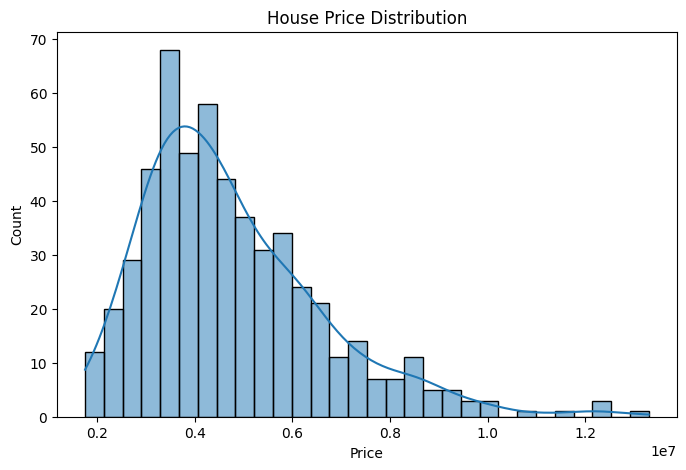

In [33]:
# Chart 1: Histogram of House Price Distribution
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=30, kde=True)

plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")

plt.savefig("price_distribution.png")
plt.show()

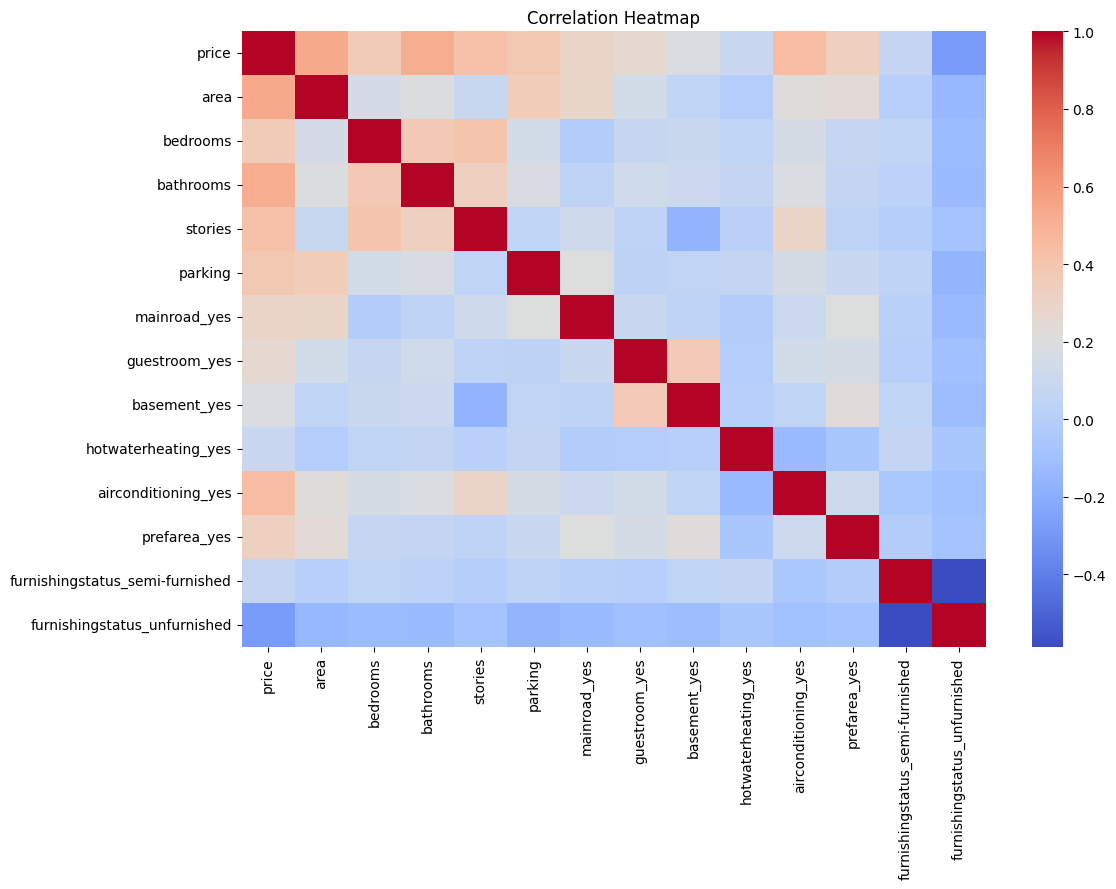

In [31]:
# Chart 2: Heatmap showing correlation
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(),cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.savefig("correlation_heatmap.png")
plt.show()

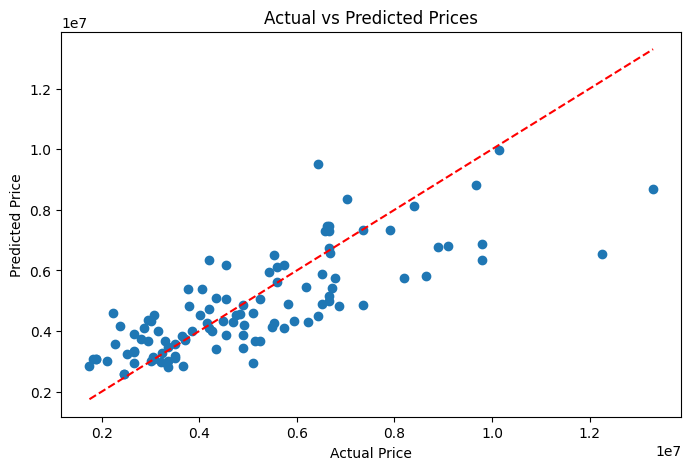

In [47]:
# Chart 3: Scatter plot of actual vs predicted prices
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred_rf)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')# Draw diagonal line

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.savefig("actual_vs_predicted.png")
plt.show()

In [ ]:
# Task 5 — Insights & Summary

In [5]:
print("The most important factors affecting house prices were area, bathrooms, parking, air conditioning, and number of stories. The Linear Regression model performed better than the Random Forest model, achieving an R^2 score of 0.653. This means the model was able to predict house prices with reasonable accuracy. A surprising finding was that house size had a much greater impact on price than other features. Real estate businesses should focus on property size and key amenities when estimating house values.")

The most important factors affecting house prices were area, bathrooms, parking, air conditioning, and number of stories. The Linear Regression model performed better than the Random Forest model, achieving an R^2 score of 0.653. This means the model was able to predict house prices with reasonable accuracy. A surprising finding was that house size had a much greater impact on price than other features. Real estate businesses should focus on property size and key amenities when estimating house values.


In [48]:
# Sorting column as per their importance 
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

                         Feature  Importance
0                           area    0.468430
2                      bathrooms    0.151483
9            airconditioning_yes    0.062672
4                        parking    0.057455
3                        stories    0.057133
1                       bedrooms    0.048413
12  furnishingstatus_unfurnished    0.035011
7                   basement_yes    0.030823
10                  prefarea_yes    0.030689
8            hotwaterheating_yes    0.017226


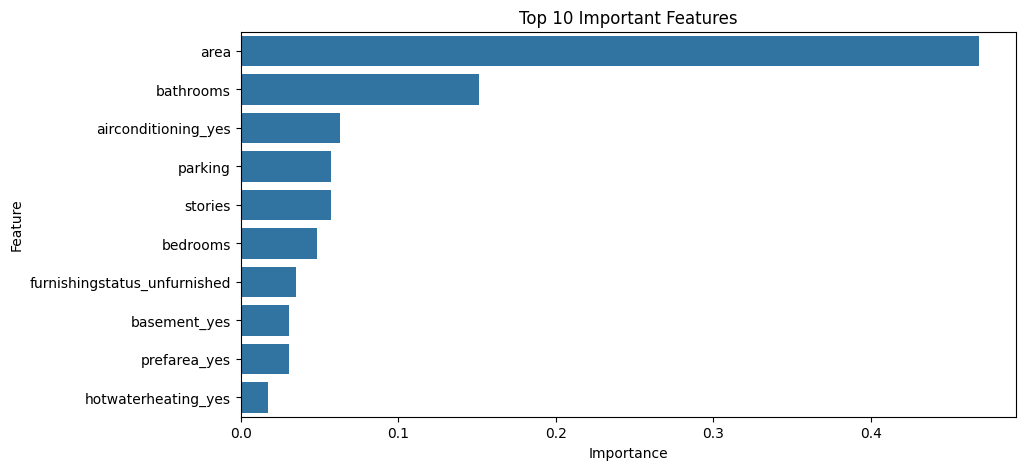

In [49]:
# Bar chart of feature importance 
plt.figure(figsize=(10,5))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()